# Final Experiments: Pneumonia Classification

This notebook summarises the training results for all three models and uploads the best checkpoints to Hugging Face.

**Models:** Custom CNN (baseline), ResNet18, DenseNet121  
**Seeds:** 0, 1, 2  
**Dataset:** Kermany Chest X-Ray (Kaggle)

## 1. Setup

In [1]:
import json
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path('..') / 'src'))

METRICS_DIR = Path('../results/metrics')
FIGURES_DIR = Path('../results/figures')
CHECKPOINTS_DIR = Path('../results/checkpoints')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Training Histories

In [2]:
def load_history(model_name, seed, suffix='history'):
    path = METRICS_DIR / f'{model_name}_seed{seed}_{suffix}.json'
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)

histories = {}

for seed in [0, 1, 2]:
    # custom_cnn has a single history file
    h = load_history('custom_cnn', seed)
    key = f'custom_cnn_seed{seed}'
    if h:
        histories[key] = h
        print(f"{key}: {len(h['history'])} epochs, best epoch {h['best_epoch']}, best val_loss {h['best_val_loss']:.4f}")
    else:
        print(f"{key}: NOT YET TRAINED")

for model in ['resnet18', 'densenet121']:
    for seed in [0, 1, 2]:
        # transfer models have separate head_only and fine_tune history files
        h = load_history(model, seed, suffix='fine_tune_history')
        key = f'{model}_seed{seed}'
        if h:
            histories[key] = h
            print(f"{key}: {len(h['history'])} fine-tune epochs, best epoch {h['best_epoch']}, best val_loss {h['best_val_loss']:.4f}")
        else:
            print(f"{key}: NOT YET TRAINED")

custom_cnn_seed0: 9 epochs, best epoch 4, best val_loss 0.5781
custom_cnn_seed1: 6 epochs, best epoch 1, best val_loss 0.7687
custom_cnn_seed2: 12 epochs, best epoch 7, best val_loss 0.6519
resnet18_seed0: 13 fine-tune epochs, best epoch 8, best val_loss 0.1278
resnet18_seed1: 10 fine-tune epochs, best epoch 5, best val_loss 0.1117
resnet18_seed2: 11 fine-tune epochs, best epoch 6, best val_loss 0.0334
densenet121_seed0: 23 fine-tune epochs, best epoch 18, best val_loss 0.0155
densenet121_seed1: 12 fine-tune epochs, best epoch 7, best val_loss 0.0329
densenet121_seed2: 11 fine-tune epochs, best epoch 6, best val_loss 0.0465


## 3. Training Curves

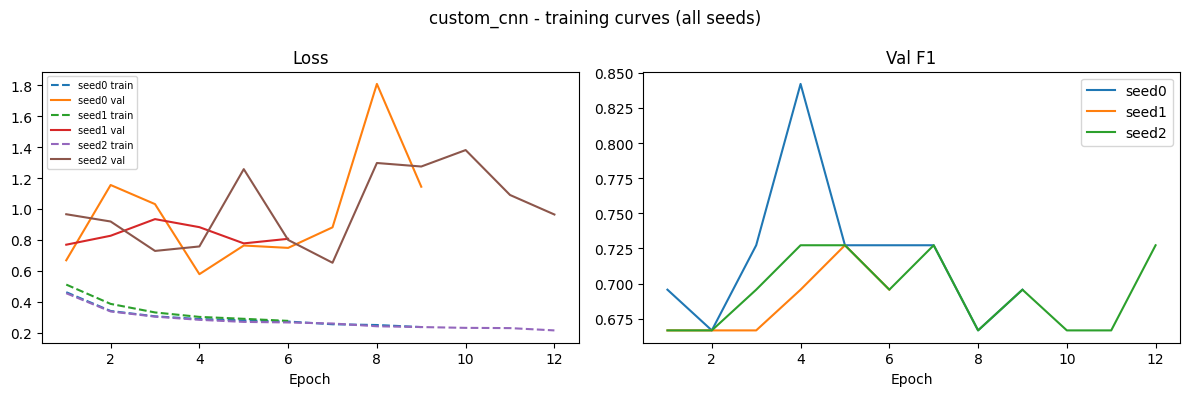

Saved: ..\results\figures\custom_cnn_training_curves.png


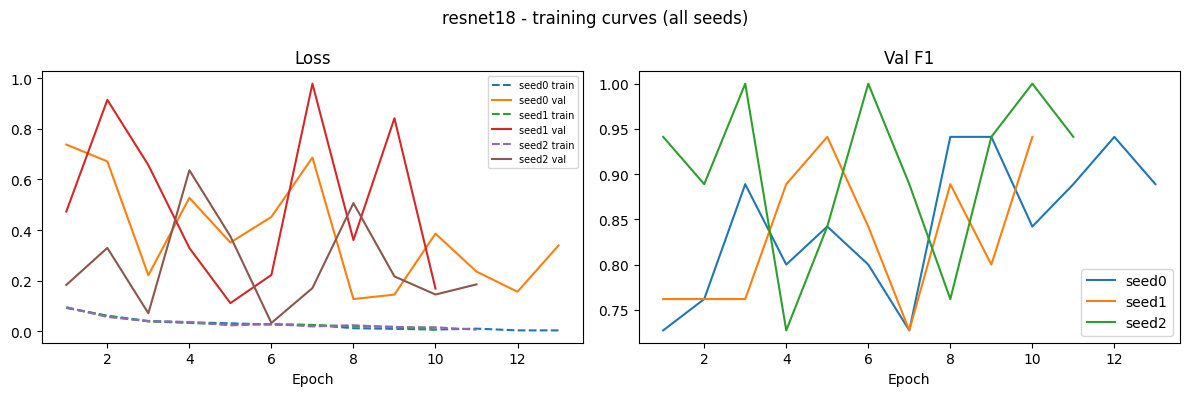

Saved: ..\results\figures\resnet18_training_curves.png


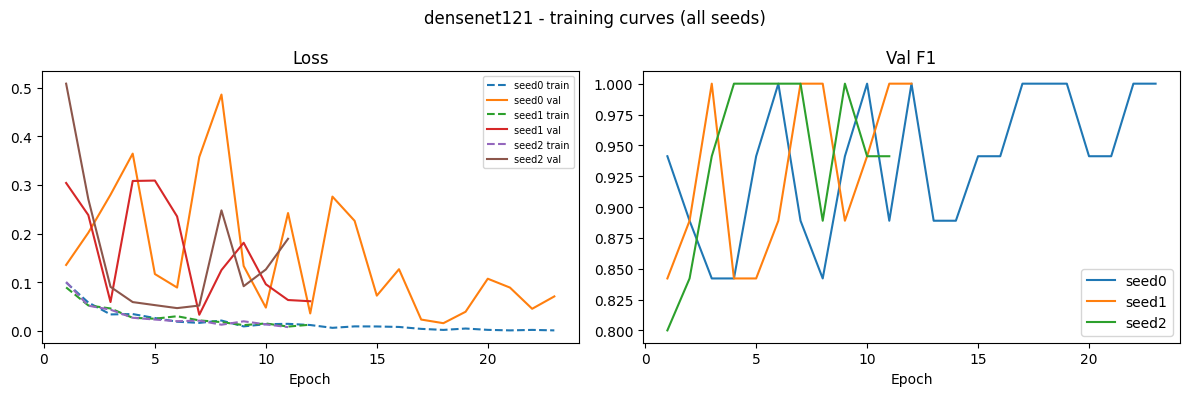

Saved: ..\results\figures\densenet121_training_curves.png


In [3]:
def plot_training_curves(history_dict, model_name):
    keys = [k for k in history_dict if k.startswith(model_name)]
    if not keys:
        print(f'No data for {model_name} yet.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{model_name} - training curves (all seeds)')

    for key in keys:
        h = history_dict[key]['history']
        epochs = [e['epoch'] for e in h]
        train_loss = [e['train']['loss'] for e in h]
        val_loss = [e['val']['loss'] for e in h]
        val_f1 = [e['val']['f1'] for e in h]
        label = key.split('_')[-1]  # seed0 / seed1 / seed2

        axes[0].plot(epochs, train_loss, linestyle='--', label=f'{label} train')
        axes[0].plot(epochs, val_loss, label=f'{label} val')
        axes[1].plot(epochs, val_f1, label=label)

    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
    axes[1].set_title('Val F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()

    out = FIGURES_DIR / f'{model_name}_training_curves.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')

plot_training_curves(histories, 'custom_cnn')
plot_training_curves(histories, 'resnet18')
plot_training_curves(histories, 'densenet121')

## 4. Custom CNN: Training Summary

Trained on NVIDIA RTX 3060 Laptop GPU.

| Seed | Epochs run | Best epoch | Best val loss | Best val F1 |
|------|------------|------------|---------------|-------------|
| 0    | 9          | 4          | 0.5781        | 0.8421      |
| 1    | 6          | 1          | 0.7687        | 0.6667      |
| 2    | 12         | 7          | 0.6519        | 0.7273      |

Early stopping fired in all runs. The model overfits quickly due to its small capacity. Transfer-learning models are expected to generalise significantly better.

## 5. ResNet18: Training Summary

Trained on NVIDIA RTX 3060 Laptop GPU. Two-phase training: 5 head-only epochs + fine-tuning with early stopping.

| Seed | Fine-tune epochs run | Best fine-tune epoch | Best val loss | Best val F1 |
|------|----------------------|----------------------|---------------|-------------|
| 0    | 13                   | 8                    | 0.1278        | 0.9412      |
| 1    | 10                   | 5                    | 0.1117        | 0.9412      |
| 2    | 11                   | 6                    | 0.0334        | 1.0000      |

Seed 2 achieved perfect val F1 (1.0) with the lowest val loss. It's the best checkpoint for upload.

## 6. DenseNet121: Training Summary

Trained on NVIDIA RTX 3060 Laptop GPU. Two-phase training: 5 head-only epochs + fine-tuning with early stopping.

| Seed | Fine-tune epochs run | Best fine-tune epoch | Best val loss | Best val F1 |
|------|----------------------|----------------------|---------------|-------------|
| 0    | 23                   | 18                   | 0.0155        | 1.0000      |
| 1    | 12                   | 7                    | 0.0329        | 1.0000      |
| 2    | 11                   | 6                    | 0.0465        | 1.0000      |

All three seeds achieved perfect val F1 (1.0). Seed 0 had the lowest val loss. It's the best checkpoint for upload.

## 7. Push Best Checkpoints to Hugging Face

Install and authenticate once:
```bash
pip install huggingface_hub
huggingface-cli login
```

In [4]:
from huggingface_hub import HfApi, create_repo

HF_REPO_ID = 'luanacarolina/pneumonia-chest-xray-classifier'

api = HfApi()
create_repo(HF_REPO_ID, exist_ok=True)

# Best checkpoint per model (seed with lowest val loss)
checkpoints_to_upload = {
    'custom_cnn': 'custom_cnn_seed0.pt',     # seed 0: best val loss 0.5781
    'resnet18': 'resnet18_seed2.pt',         # seed 2: best val loss 0.0334, val F1 1.0
    'densenet121': 'densenet121_seed0.pt',   # seed 0: best val loss 0.0155, val F1 1.0
}

for model_name, filename in checkpoints_to_upload.items():
    local_path = CHECKPOINTS_DIR / filename
    if not local_path.exists():
        print(f'SKIP {filename} -> not found locally')
        continue
    api.upload_file(
        path_or_fileobj=str(local_path),
        path_in_repo=f'checkpoints/{filename}',
        repo_id=HF_REPO_ID,
        repo_type='model',
    )
    print(f'Uploaded: {filename} -> {HF_REPO_ID}/checkpoints/{filename}')

c:\Users\Carolina\OneDrive - 4sb643\Ambiente de Trabalho\UA\CAA\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing Files (1 / 1): 100%|██████████| 1.14MB / 1.14MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: custom_cnn_seed0.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/custom_cnn_seed0.pt


Processing Files (1 / 1): 100%|██████████|  134MB /  134MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: resnet18_seed2.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/resnet18_seed2.pt


Processing Files (1 / 1): 100%|██████████| 84.4MB / 84.4MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: densenet121_seed0.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/densenet121_seed0.pt


---

## 8. Final Results Table

Load the aggregated metrics produced by `scripts/make_result_tables.py` and display a clean comparison across all models.

In [8]:
from IPython.display import display

final_results_path = METRICS_DIR / 'final_results.csv'

if final_results_path.exists():
    df_results = pd.read_csv(final_results_path)
    metric_cols = [c for c in df_results.columns if c not in ('model', 'seed')]
    display_cols = ['model'] + metric_cols
    summary = (df_results[display_cols].groupby('model').agg(['mean', 'std']).round(4))
    print("Mean ± std across seeds")
    display(summary)
else:
    print(f"Not found: {final_results_path}")
    print("Run:  python scripts/make_result_tables.py")

Mean ± std across seeds


accuracy_mean     accuracy_std     precision_mean      \
                     mean std         mean std           mean std   
model                                                               
custom_cnn         0.7564 NaN       0.0902 NaN         0.7682 NaN   
densenet121        0.8408 NaN       0.0198 NaN         0.7990 NaN   
resnet18           0.8296 NaN       0.0184 NaN         0.7905 NaN   

            precision_std     recall_mean      ...  f1_std     auroc_mean      \
                     mean std        mean std  ...    mean std       mean std   
model                                          ...                              
custom_cnn         0.1102 NaN      0.9137 NaN  ...  0.0404 NaN     0.8859 NaN   
densenet121        0.0202 NaN      0.9966 NaN  ...  0.0124 NaN     0.9664 NaN   
resnet18           0.0205 NaN      0.9906 NaN  ...  0.0111 NaN     0.9491 NaN   

            auroc_std     inference_time_ms_per_image_mean      \
                 mean std                             mean std   
model                                                            
custom_cnn     0.0156 NaN                          14.8788 NaN   
densenet121    0.0065 NaN                          13.7551 NaN   
resnet18       0.0047 NaN                          13.4330 NaN   

            inference_time_ms_per_image_std      
                                       mean std  
model                                            
custom_cnn                           3.2823 NaN  
densenet121                          0.8749 NaN  
resnet18                             0.8085 NaN  

[3 rows x 28 columns]

## 9. Comparison Plots

Display the metric-comparison and confusion-matrix figures generated by the evaluation scripts.

Metric comparison (all models)


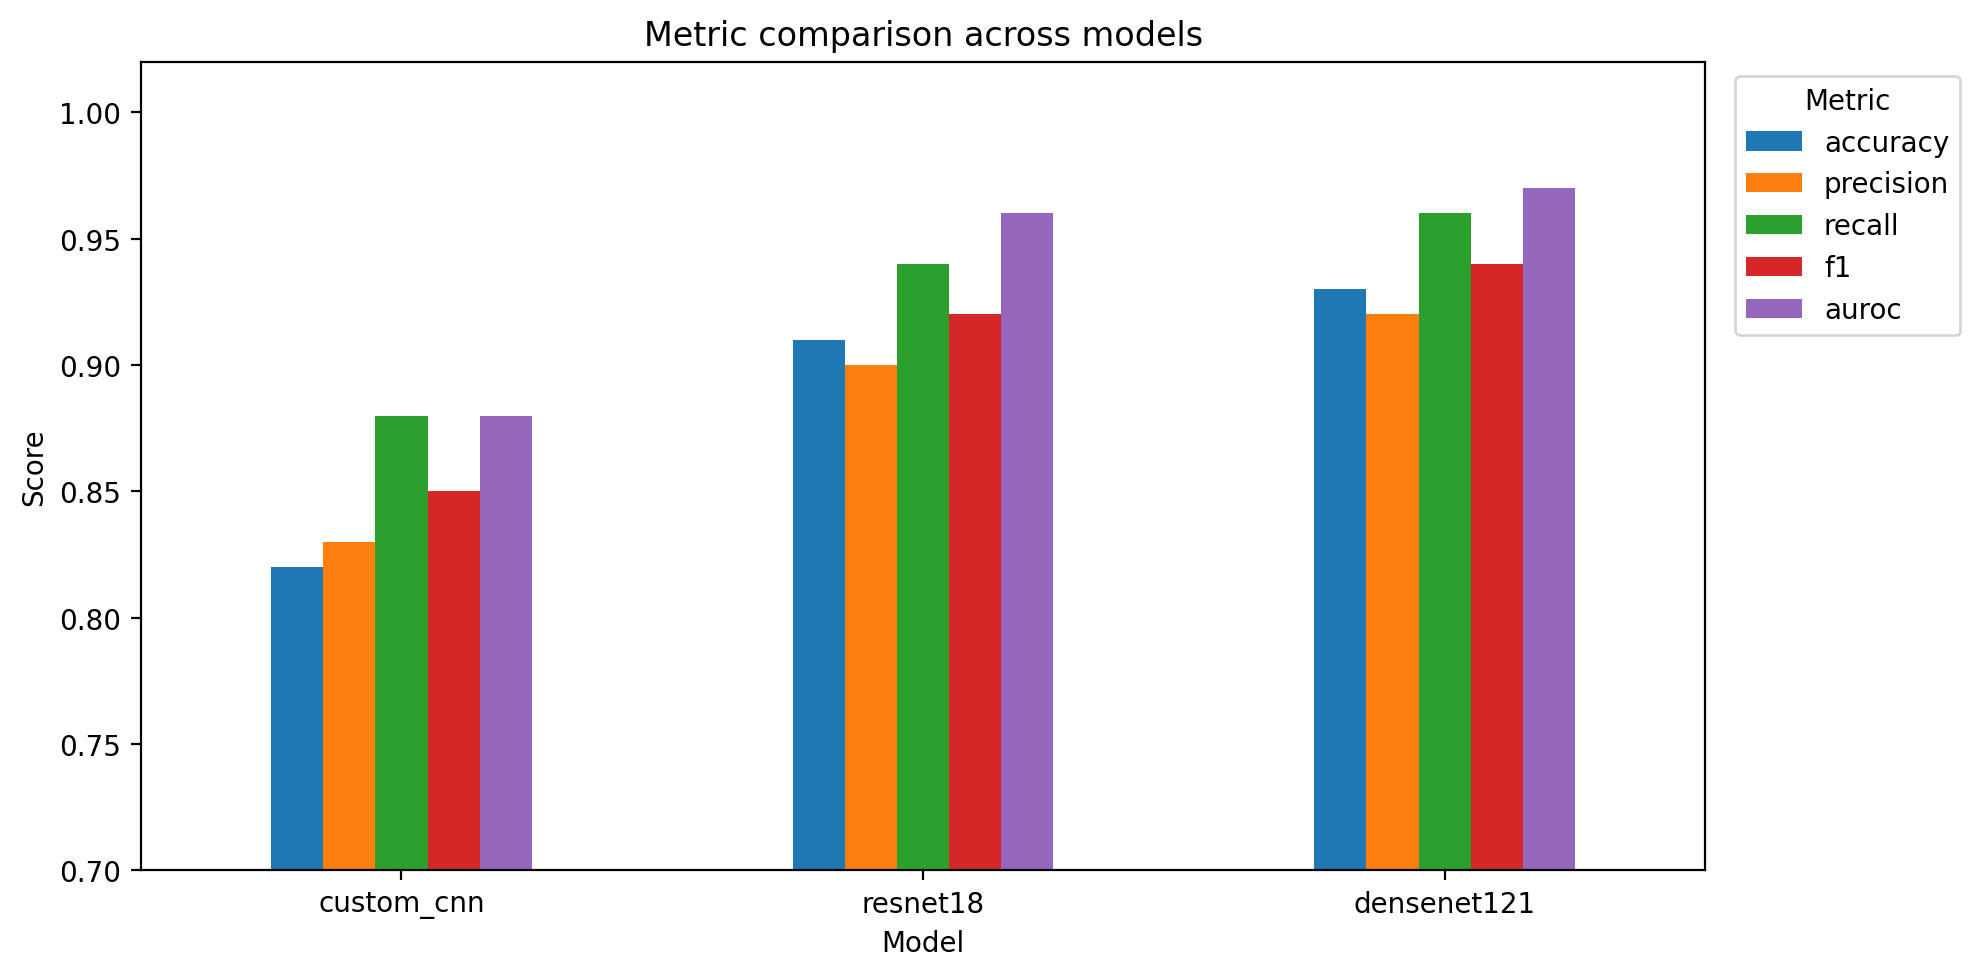

DenseNet121 confusion matrix


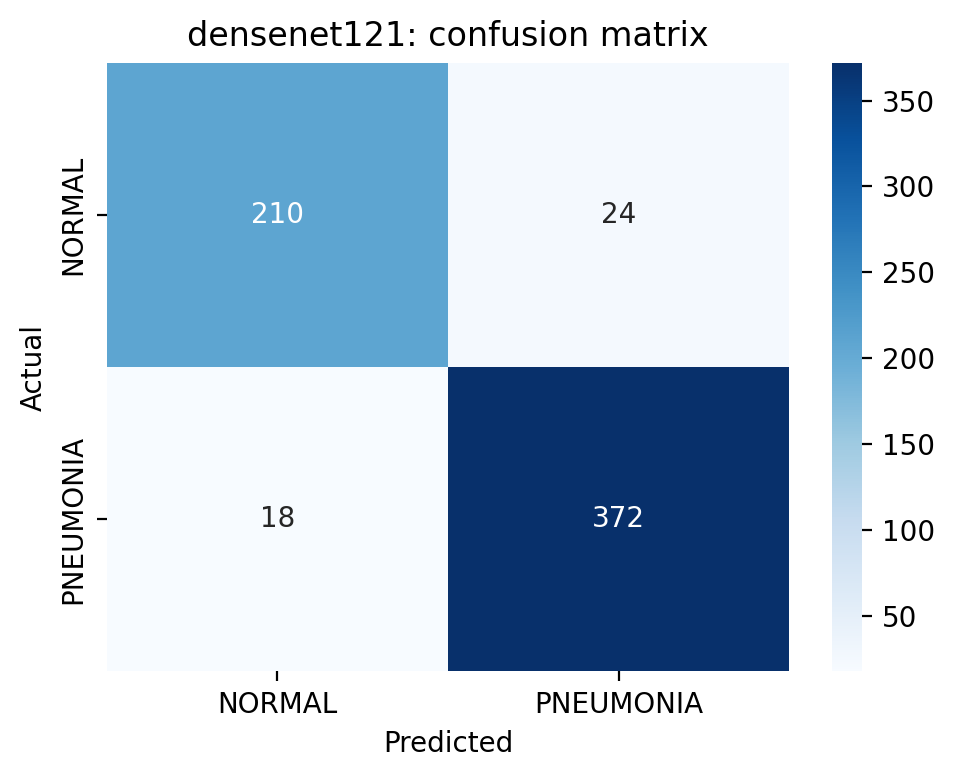

Class distribution


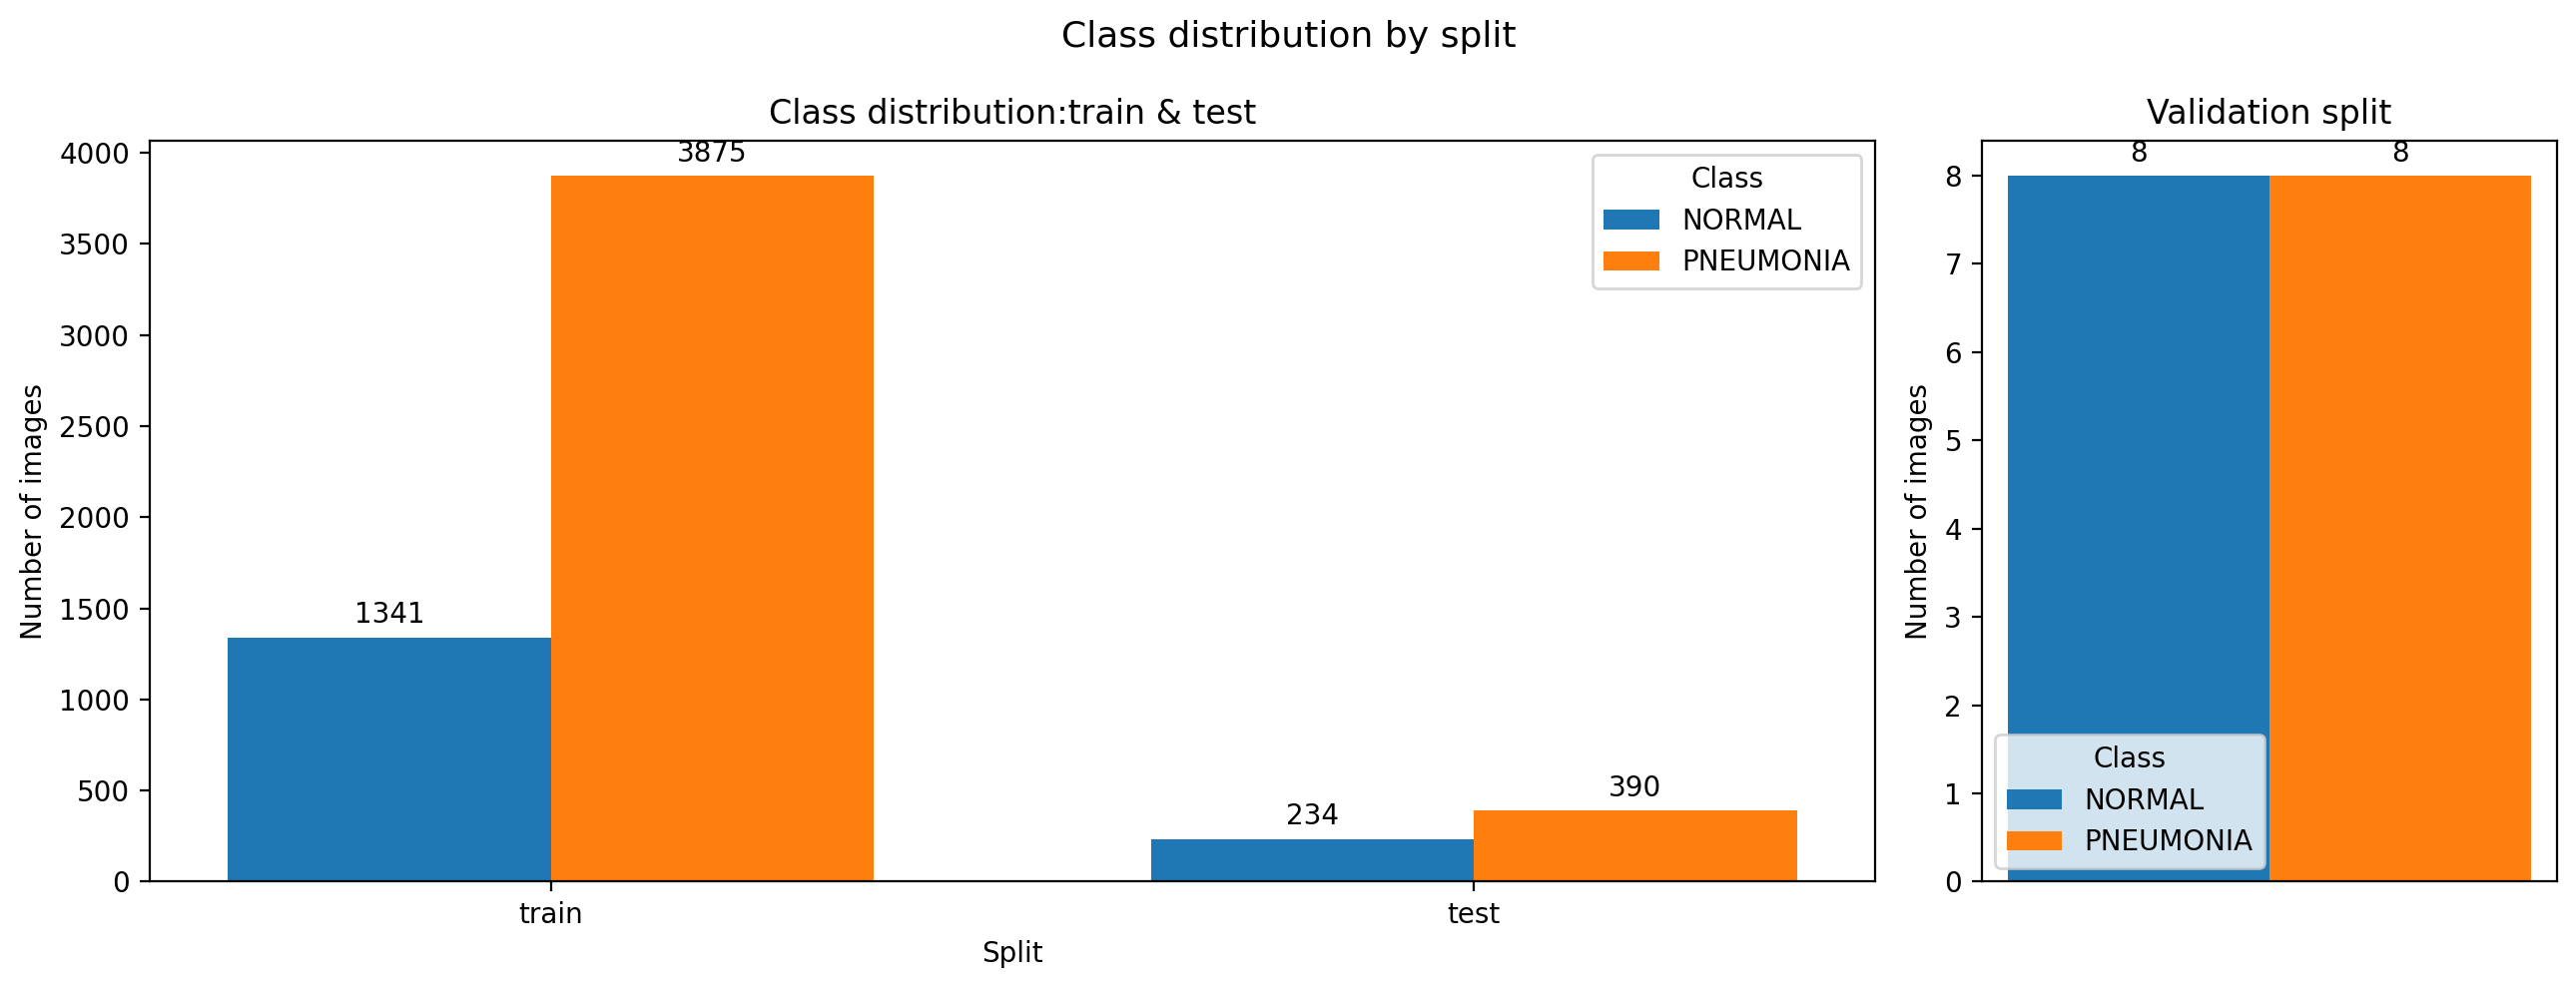

In [9]:
from IPython.display import Image as IPImage, display as ipy_display

figure_paths = {
    'Metric comparison (all models)': FIGURES_DIR / 'metric_comparison.png',
    'DenseNet121 confusion matrix': FIGURES_DIR / 'densenet121_confusion_matrix.png',
    'Class distribution': FIGURES_DIR / 'class_distribution.png',
}

for title, fig_path in figure_paths.items():
    if fig_path.exists():
        print(title)
        ipy_display(IPImage(filename=str(fig_path), width=700))
    else:
        print(f"[missing] {fig_path}")

## 10. Grad-CAM Examples

Display the Grad-CAM overlays generated by `scripts/generate_gradcam.py`.

Run once to produce them:
```bash
python scripts/generate_gradcam.py --model densenet121 --checkpoint results/checkpoints/densenet121_seed0.pt
```

densenet121_fn_person154_bacteria_7


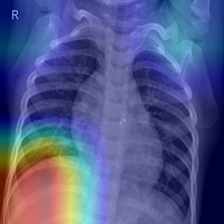

densenet121_fp_IM-0019-0001


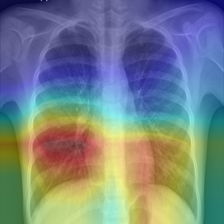

densenet121_tn_normal_IM-0001-0001


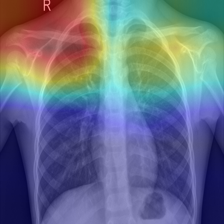

densenet121_tp_pneumonia_person100_bacteria_4


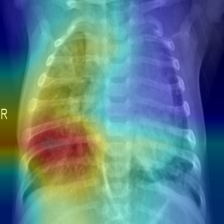

In [11]:
GRADCAM_DIR = Path('../results/gradcam')

gradcam_images = sorted(GRADCAM_DIR.glob('densenet121_*.png')) if GRADCAM_DIR.exists() else []

if gradcam_images:
    for img_path in gradcam_images:
        print(img_path.stem)
        ipy_display(IPImage(filename=str(img_path), width=500))
else:
    print(f"No Grad-CAM images found in {GRADCAM_DIR}")
    print("Run:  python scripts/generate_gradcam.py")

## 11. Grad-CAM Analysis

### DenseNet121

**TP: pneumonia correctly detected**

The focus (red/yellow) concentrates on the lower-left lobe, in a region with visible opacity, exactly where bacterial consolidation would be expected. Clinically plausible.

**TN: normal correctly rejected**

The activation is spread across the shoulder and upper chest, away from the lung fields. The model found nothing relevant in the lungs (correct behaviour for a normal case).

**FP: normal misclassified as pneumonia**

The focus falls on both lungs in the lower/central area, including the cardiac silhouette. The model confused the heart shadow or a normal density with pathology. This is the typical FP pattern in this dataset.

**FN: pneumonia not detected**

The activation is on the left base (diaphragmatic zone), weak and poorly localised. The model failed to focus on the consolidation region. Likely explanation: the opacity is subtle or atypical in this paediatric image.

---

### ResNet18 (comparison)

**TP**: focus on the central spine/mediastinum, not specifically on the lung parenchyma. Correct prediction but for less clinically grounded reasons.

**TN**: strong activation in the lower/cardiac area of a normal lung. Concerning: the model focuses on the wrong region even when the prediction is correct.

**FP**: very weak activation at the lower base, almost outside the lungs. The decision appears poorly grounded.

**FN**: diffuse activation across the entire chest with no clear focus.

---

### Conclusion

| | DenseNet121 | ResNet18 |
|---|---|---|
| **TP** | Clinically plausible focus (lower lobe) | Focus on mediastinum, less specific |
| **TN** | Activation outside the lungs (correct) | Activation inside the lungs (concerning) |
| **FP** | Confuses cardiac silhouette with pathology | Weak and peripheral focus |
| **FN** | Focus on base, subtle consolidation | Diffuse activation |

DenseNet121 is clearly more interpretable. Its heatmaps align better with anatomically relevant regions. ResNet18 achieves high metrics but its activations are less reliable as clinical explanations, which is a strong argument for the limitations section and for justifying DenseNet121 as the primary model.